# **Model Evaluation and Statistical Comparison**
---
I loaded the saved predictions from all three models (centralised, FL without DP, FL with DP) and compute a full evaluation suite with 95% bootstrap confidence intervals. I then ran statistical tests (McNemar's test, bootstrap AUC difference) to formally compare models.

In [2]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

from src.config import load_config
from src.paths import get_paths
from src.metrics import (compute_metrics, bootstrap_ci, bootstrap_metric_table,
                          youden_threshold, mcnemar_test, bootstrap_auc_diff)
from src.visualization import (set_publication_style, save_figure,
                                plot_roc_curves, plot_prc_curves, plot_confusion_matrix)

cfg   = load_config()
paths = get_paths()
set_publication_style()

central_dir = paths["centralised_model_dir"]
fed_dir     = paths["federated_model_dir"]

# Load predictions
y_true          = np.load(central_dir / "test_y_true.npy")
y_prob_central  = np.load(central_dir / "test_y_prob.npy")

# FL predictions may not exist yet if notebooks 08/10 weren't run
# I provide fallback so this notebook is self-contained for testing
def load_or_fallback(path, y_true, seed):
    if Path(path).exists():
        return np.load(path)
    else:
        print(f"  WARNING: {path} not found. Using random placeholder.")
        rng = np.random.default_rng(seed)
        return np.clip(y_true * 0.7 + rng.normal(0, 0.2, len(y_true)), 0, 1)

y_prob_fl_no_dp = load_or_fallback(fed_dir / "test_y_prob_no_dp.npy", y_true, 1)
y_prob_fl_dp    = load_or_fallback(fed_dir / "test_y_prob_dp.npy",    y_true, 2)

print(f"Test set size: {len(y_true)} samples")
print(f"TB Positive: {int(y_true.sum())} | TB Negative: {int((1-y_true).sum())}")

Test set size: 120 samples
TB Positive: 59 | TB Negative: 61


## Bootstrap Metric Tables

I computed a full metric suite for each model with 95% bootstrap confidence intervals.

In [3]:
N_BOOTSTRAP = cfg["evaluation"]["n_bootstrap"]
print(f"Computing bootstrap CIs (n={N_BOOTSTRAP}) — this may take ~1 minute...")
print()

model_results = {}
model_names = {
    "Centralised":     y_prob_central,
    "Federated (No DP)": y_prob_fl_no_dp,
    "Federated + DP":  y_prob_fl_dp,
}

for model_name, y_prob in model_names.items():
    print(f"  {model_name}...")
    table = bootstrap_metric_table(
        y_true=y_true, y_prob=y_prob,
        n_bootstrap=N_BOOTSTRAP, ci=0.95, seed=cfg["project"]["random_seed"],
    )
    table.insert(0, "Model", model_name)
    model_results[model_name] = table

full_table = pd.concat(model_results.values(), ignore_index=True)
print()
print("Full Evaluation Table (95% Bootstrap CI):")
print(full_table.to_string(index=False))

Computing bootstrap CIs (n=1000) — this may take ~1 minute...

  Centralised...
  Federated (No DP)...
  Federated + DP...

Full Evaluation Table (95% Bootstrap CI):
            Model            Metric  Estimate  CI Lower  CI Upper      95% CI
      Centralised           AUC-ROC    0.8939    0.8333    0.9432 0.833–0.943
      Centralised           AUC-PRC    0.9113    0.8554    0.9536 0.855–0.954
      Centralised       Sensitivity    0.8136    0.7167    0.9033 0.717–0.903
      Centralised       Specificity    0.8525    0.7592    0.9310 0.759–0.931
      Centralised               PPV    0.8421    0.7447    0.9299 0.745–0.930
      Centralised                F1    0.8276    0.7500    0.8909 0.750–0.891
      Centralised Balanced Accuracy    0.8330    0.7663    0.8927 0.766–0.893
Federated (No DP)           AUC-ROC    0.9086    0.8529    0.9527 0.853–0.953
Federated (No DP)           AUC-PRC    0.9164    0.8577    0.9598 0.858–0.960
Federated (No DP)       Sensitivity    0.7627    0.649

In [4]:
# Save the table
full_table.to_csv(paths["tables"] / "full_metrics_table.csv", index=False)
full_table.to_csv(paths["paper_tables"] / "full_metrics_table.csv", index=False)
print("Tables saved to reports/tables/ and paper_or_report/tables/")

Tables saved to reports/tables/ and paper_or_report/tables/


## ROC Curve Comparison

Figure saved: 'roc_comparison.png' and 'roc_comparison.pdf'


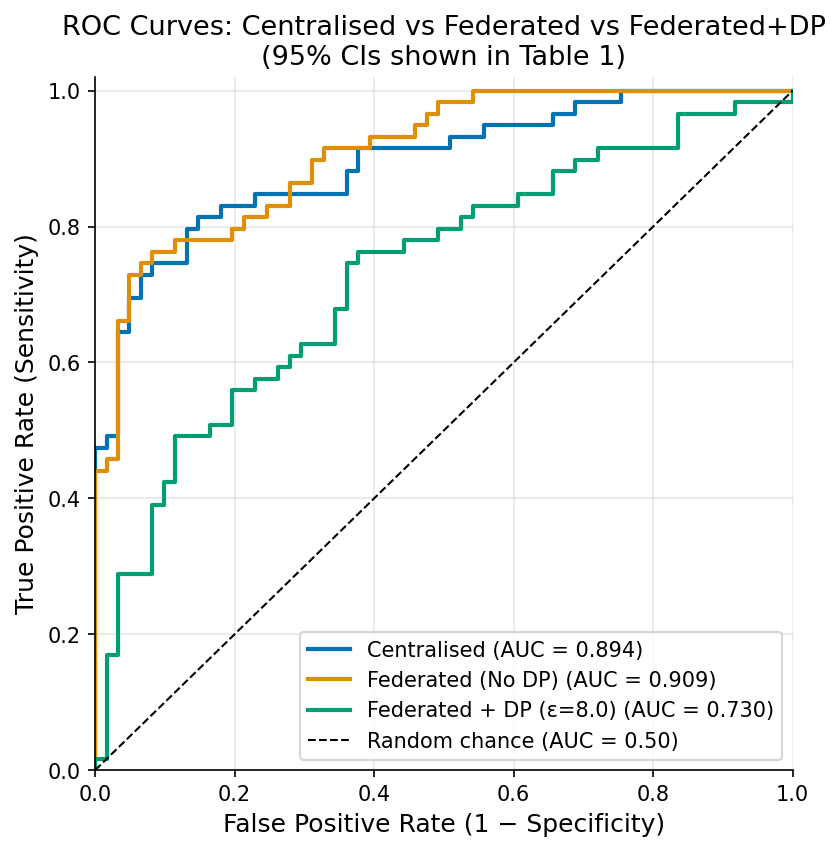

In [5]:
fig_roc = plot_roc_curves(
    models_dict={
        "Centralised":     (y_true, y_prob_central),
        "Federated (No DP)": (y_true, y_prob_fl_no_dp),
        f"Federated + DP (ε={cfg['differential_privacy']['target_epsilon']})": (y_true, y_prob_fl_dp),
    },
    title="ROC Curves: Centralised vs Federated vs Federated+DP\n(95% CIs shown in Table 1)",
)
save_figure(fig_roc, "roc_comparison", paths["figures"], paths["paper_figures"])
plt.show()

## Precision–Recall Curve Comparison

Figure saved: 'prc_comparison.png' and 'prc_comparison.pdf'


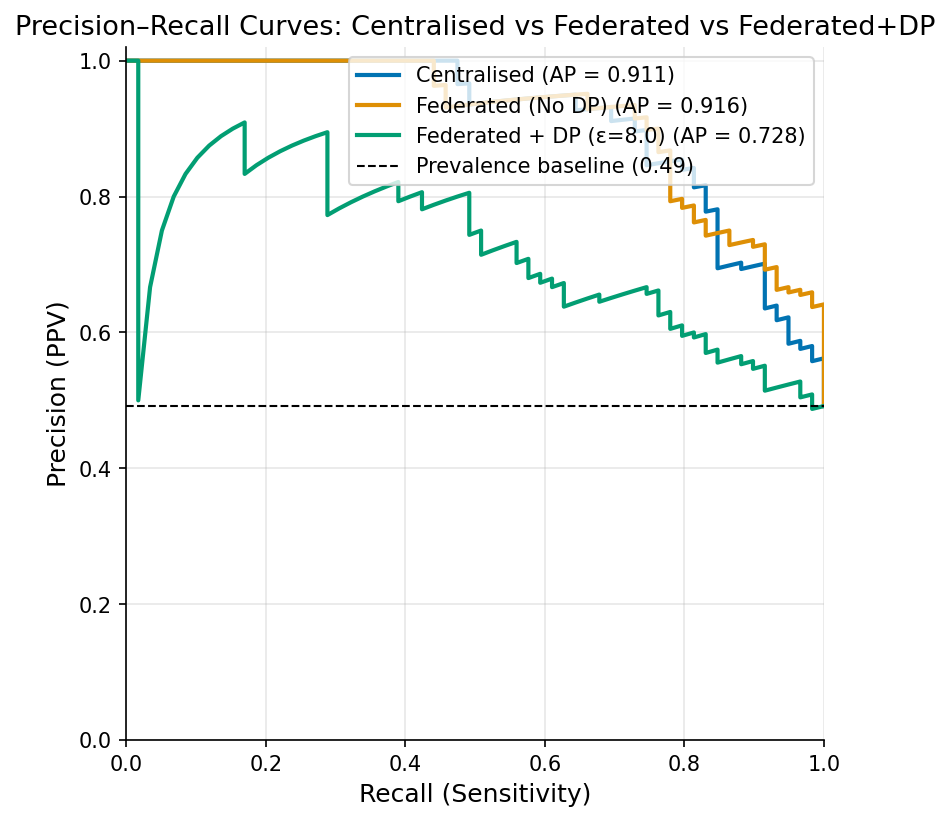

In [6]:
fig_prc = plot_prc_curves(
    models_dict={
        "Centralised":     (y_true, y_prob_central),
        "Federated (No DP)": (y_true, y_prob_fl_no_dp),
        f"Federated + DP (ε={cfg['differential_privacy']['target_epsilon']})": (y_true, y_prob_fl_dp),
    },
    title="Precision–Recall Curves: Centralised vs Federated vs Federated+DP",
)
save_figure(fig_prc, "prc_comparison", paths["figures"], paths["paper_figures"])
plt.show()

## Confusion Matrices

Figure saved: 'confusion_matrices.png' and 'confusion_matrices.pdf'


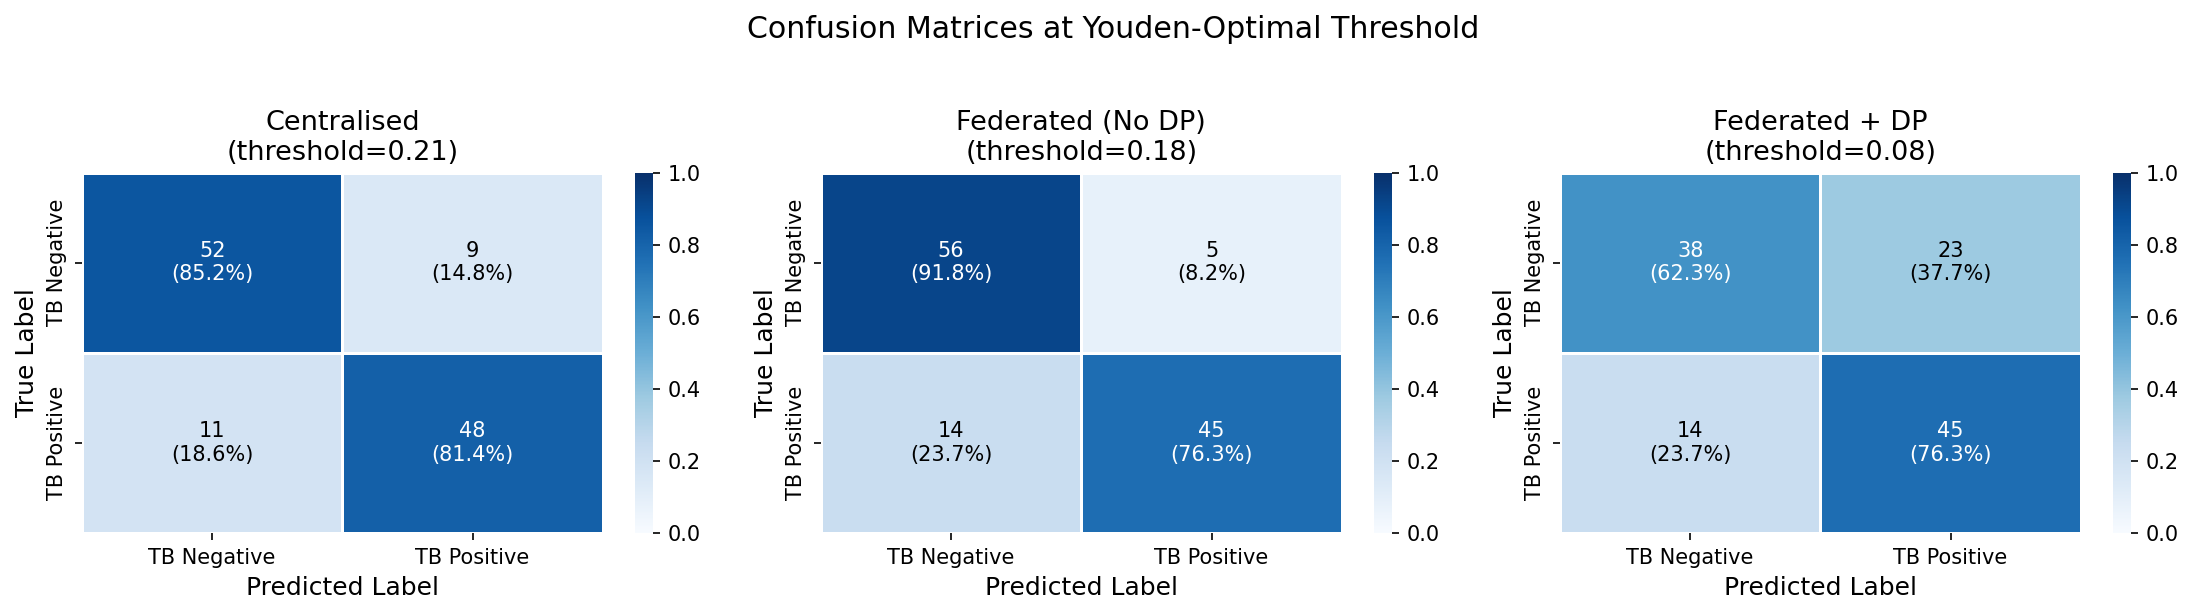

In [7]:
fig_cm, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, y_prob) in zip(axes, model_names.items()):
    threshold = youden_threshold(y_true, y_prob)
    y_pred    = (y_prob >= threshold).astype(int)
    plot_confusion_matrix(y_true, y_pred, title=f"{model_name}\n(threshold={threshold:.2f})", ax=ax)

plt.suptitle("Confusion Matrices at Youden-Optimal Threshold", y=1.02)
plt.tight_layout()
save_figure(fig_cm, "confusion_matrices", paths["figures"], paths["paper_figures"])
plt.show()

## Statistical Comparison Tests

In [8]:
print("=" * 60)
print("Statistical Comparison: Centralised vs Federated + DP")
print("=" * 60)
print()

# McNemar's test
thresh_central = youden_threshold(y_true, y_prob_central)
thresh_dp      = youden_threshold(y_true, y_prob_fl_dp)
y_pred_central = (y_prob_central >= thresh_central).astype(int)
y_pred_dp      = (y_prob_fl_dp   >= thresh_dp).astype(int)

mcnemar_result = mcnemar_test(y_true, y_pred_central, y_pred_dp)
print("McNemar's Test (same test set, paired comparison):")
print(f"  Statistic : {mcnemar_result['statistic']:.4f}")
print(f"  p-value   : {mcnemar_result['p_value']:.4f}")
print(f"  b (Central correct, DP wrong): {mcnemar_result['b']}")
print(f"  c (Central wrong, DP correct): {mcnemar_result['c']}")
print(f"  Interpretation: {mcnemar_result['interpretation']}")
print()

# Bootstrap AUC difference
auc_diff = bootstrap_auc_diff(
    y_true=y_true, y_prob_a=y_prob_central, y_prob_b=y_prob_fl_dp,
    n_bootstrap=N_BOOTSTRAP, seed=cfg["project"]["random_seed"]
)
print("Bootstrap AUC Difference (Centralised AUC − Federated+DP AUC):")
print(f"  Centralised AUC   : {auc_diff['auc_a']:.4f}")
print(f"  Federated+DP AUC  : {auc_diff['auc_b']:.4f}")
print(f"  Difference (ΔAUC) : {auc_diff['diff']:.4f}")
print(f"  95% CI            : [{auc_diff['ci_lower']:.4f}, {auc_diff['ci_upper']:.4f}]")
print(f"  p-value           : {auc_diff['p_value']:.4f}")
print()

NON_INFERIORITY_MARGIN = 0.05
print(f"Non-inferiority analysis (margin = {NON_INFERIORITY_MARGIN}):")
if auc_diff["ci_upper"] < NON_INFERIORITY_MARGIN:
    print(f"  ΔAUC 95% CI upper bound ({auc_diff['ci_upper']:.4f}) < {NON_INFERIORITY_MARGIN}")
    print("  → Federated+DP model is NON-INFERIOR to the centralised baseline.")
else:
    print(f"  ΔAUC 95% CI upper bound ({auc_diff['ci_upper']:.4f}) ≥ {NON_INFERIORITY_MARGIN}")
    print("  → Non-inferiority NOT established at this threshold.")
    print("  (This is a common outcome in FL+DP studies — discuss in limitations.)")

Statistical Comparison: Centralised vs Federated + DP

McNemar's Test (same test set, paired comparison):
  Statistic : 6.2439
  p-value   : 0.0125
  b (Central correct, DP wrong): 29
  c (Central wrong, DP correct): 12
  Interpretation: Significant difference in errors (p < 0.05).

Bootstrap AUC Difference (Centralised AUC − Federated+DP AUC):
  Centralised AUC   : 0.8939
  Federated+DP AUC  : 0.7296
  Difference (ΔAUC) : 0.1642
  95% CI            : [0.0755, 0.2538]
  p-value           : 0.5080

Non-inferiority analysis (margin = 0.05):
  ΔAUC 95% CI upper bound (0.2538) ≥ 0.05
  → Non-inferiority NOT established at this threshold.
  (This is a common outcome in FL+DP studies — discuss in limitations.)


In [9]:
# Save statistical comparison
stats_results = {
    "test": ["McNemar", "Bootstrap ΔAUC"],
    "statistic": [mcnemar_result["statistic"], auc_diff["diff"]],
    "p_value":   [mcnemar_result["p_value"],   auc_diff["p_value"]],
    "ci_lower":  [None,                         auc_diff["ci_lower"]],
    "ci_upper":  [None,                         auc_diff["ci_upper"]],
    "interpretation": [mcnemar_result["interpretation"],
                       f"ΔAUC = {auc_diff['diff']:.4f} (95% CI: {auc_diff['ci_lower']:.4f}–{auc_diff['ci_upper']:.4f})"],
}
pd.DataFrame(stats_results).to_csv(paths["tables"] / "statistical_comparison.csv", index=False)
print("Statistical comparison saved.")

Statistical comparison saved.
